In [6]:
import pandas as pd

new_df = pd.read_csv('../data/extended_crop_data.csv', nrows=5)

new_df.head()

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120,0.75


In [7]:
print(new_df.columns)

Index(['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ',
       'Production', 'Yield'],
      dtype='object')


In [8]:
import pandas as pd

new_df = pd.read_csv(
    '../data/extended_crop_data.csv',
    usecols=['State', 'Crop', 'Crop_Year', 'Area ', 'Production']
)

new_df.head()

,State,Crop,Crop_Year,Area,Production
0,Andaman and Nicobar Island,Arecanut,2007,2439.6,3415.0
1,Andaman and Nicobar Island,Arecanut,2007,1626.4,2277.0
2,Andaman and Nicobar Island,Arecanut,2008,4147.0,3060.0
3,Andaman and Nicobar Island,Arecanut,2008,4147.0,2660.0
4,Andaman and Nicobar Island,Arecanut,2009,4153.0,3120.0


In [9]:
new_df = new_df.rename(columns={
    'Crop_Year': 'Year',
    'Area ': 'Area_ha'
})

new_df.head()

,State,Crop,Year,Area_ha,Production
0,Andaman and Nicobar Island,Arecanut,2007,2439.6,3415.0
1,Andaman and Nicobar Island,Arecanut,2007,1626.4,2277.0
2,Andaman and Nicobar Island,Arecanut,2008,4147.0,3060.0
3,Andaman and Nicobar Island,Arecanut,2008,4147.0,2660.0
4,Andaman and Nicobar Island,Arecanut,2009,4153.0,3120.0


In [10]:
new_df = new_df[
    (new_df['State'] == 'Tamil Nadu') &
    (new_df['Crop'] == 'Rice')
]

In [11]:
new_df['Yield_kg_per_ha'] = (new_df['Production'] * 1000) / new_df['Area_ha']

In [12]:
new_df = new_df[['Year', 'Yield_kg_per_ha']]

In [13]:
new_df = new_df[new_df['Year'] > 2017]

In [14]:
old_df = pd.read_csv('../data/tamilnadu_rice_2000_2017.csv')
old_df = old_df[['Year', 'Yield_kg_per_ha']]

In [15]:
combined_df = pd.concat([old_df, new_df], ignore_index=True)

combined_df = combined_df.drop_duplicates()
combined_df = combined_df.sort_values(by='Year')

combined_df.head()

,Year,Yield_kg_per_ha
0,2000,3385.27
162,2000,4427.48
144,2000,2255.89
126,2000,4350.16
108,2000,3644.38


In [16]:
print(combined_df['Year'].min(), combined_df['Year'].max())

2000 2019


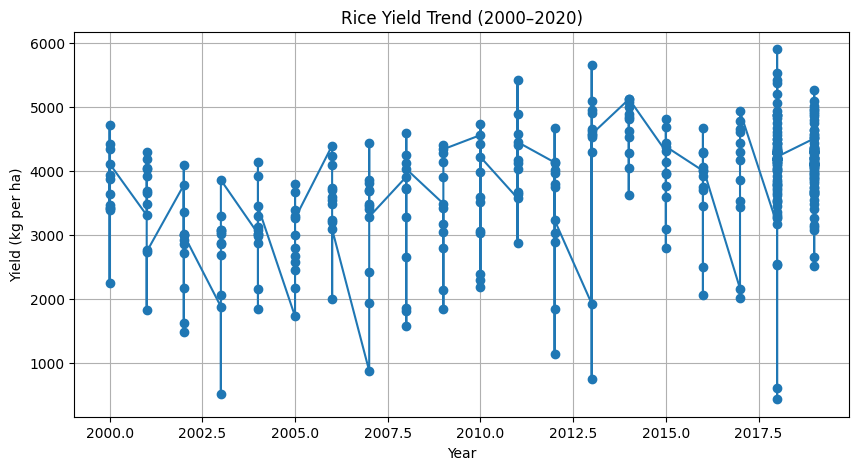

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(combined_df['Year'], combined_df['Yield_kg_per_ha'], marker='o')
plt.xlabel('Year')
plt.ylabel('Yield (kg per ha)')
plt.title('Rice Yield Trend (2000–2020)')
plt.grid(True)
plt.show()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [20]:
old_df = pd.read_csv('../data/tamilnadu_rice_2000_2017.csv')
old_df = old_df[['Year', 'Yield_kg_per_ha']]

In [21]:
new_df = pd.read_csv(
    '../data/extended_crop_data.csv',
    usecols=['State', 'Crop', 'Crop_Year', 'Area ', 'Production']
)

new_df = new_df.rename(columns={
    'Crop_Year': 'Year',
    'Area ': 'Area_ha'
})

new_df = new_df[
    (new_df['State'] == 'Tamil Nadu') &
    (new_df['Crop'] == 'Rice')
]

new_df['Yield_kg_per_ha'] = (new_df['Production'] * 1000) / new_df['Area_ha']

new_df = new_df[['Year', 'Yield_kg_per_ha']]
new_df = new_df[new_df['Year'] > 2017]

In [22]:
combined_df = pd.concat([old_df, new_df], ignore_index=True)
combined_df = combined_df.drop_duplicates()
combined_df = combined_df.sort_values(by='Year')

combined_df.head()

,Year,Yield_kg_per_ha
0,2000,3385.27
162,2000,4427.48
144,2000,2255.89
126,2000,4350.16
108,2000,3644.38


In [24]:
print(combined_df.isna().sum())

Year               0
Yield_kg_per_ha    2
dtype: int64


In [25]:
combined_df = combined_df.dropna()

In [26]:
combined_df = combined_df[combined_df['Yield_kg_per_ha'] > 0]

In [27]:
print(combined_df.isna().sum())

Year               0
Yield_kg_per_ha    0
dtype: int64


In [28]:
X = combined_df['Year'].values.reshape(-1,1)
y = combined_df['Yield_kg_per_ha'].values

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
combined_df = combined_df.dropna(subset=['Yield_kg_per_ha'])

In [30]:
future_years = np.array([[2024], [2025]])

predictions = model.predict(future_years)

future_df = pd.DataFrame({
    'Year': [2024, 2025],
    'Yield_kg_per_ha': predictions
})

future_df

,Year,Yield_kg_per_ha
0,2024,4456.566270
1,2025,4516.114007


In [31]:
final_df = pd.concat([combined_df, future_df], ignore_index=True)

final_df = final_df.sort_values(by='Year')

final_df.tail()

,Year,Yield_kg_per_ha
327,2019,4205.408070
326,2019,4635.261583
335,2019,3881.839810
390,2024,4456.566270
391,2025,4516.114007


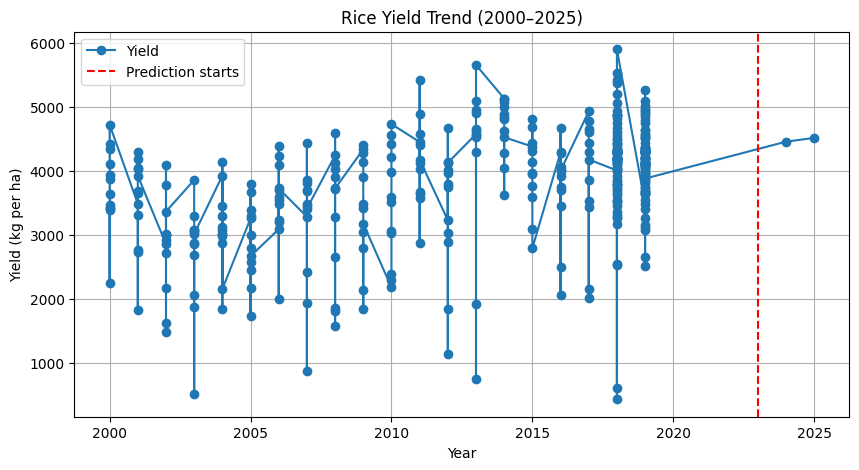

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(final_df['Year'], final_df['Yield_kg_per_ha'], marker='o', label='Yield')

plt.axvline(x=2023, color='red', linestyle='--', label='Prediction starts')

plt.xlabel('Year')
plt.ylabel('Yield (kg per ha)')
plt.title('Rice Yield Trend (2000–2025)')
plt.legend()
plt.grid(True)

plt.show()

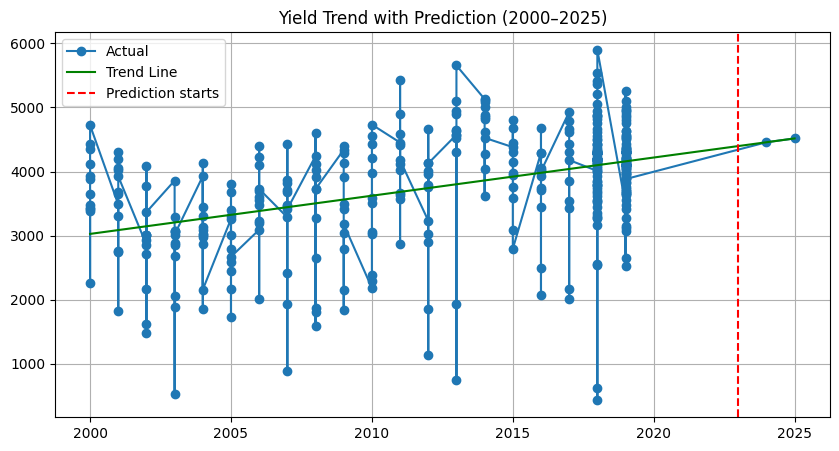

In [33]:
trend = model.predict(final_df['Year'].values.reshape(-1,1))

plt.figure(figsize=(10,5))

plt.plot(final_df['Year'], final_df['Yield_kg_per_ha'], marker='o', label='Actual')
plt.plot(final_df['Year'], trend, color='green', label='Trend Line')

plt.axvline(x=2023, color='red', linestyle='--', label='Prediction starts')

plt.legend()
plt.grid(True)
plt.title('Yield Trend with Prediction (2000–2025)')

plt.show()